In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs visible: {len(gpus)}", ("✅ Using GPU" if gpus else "⚠️ No GPU"))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping


E0000 00:00:1757869861.293288      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757869861.353555      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPUs visible: 1 ✅ Using GPU


In [5]:
DATASET_PATH = "/kaggle/input/skin-cancer-mnist-ham10000/"
meta_csv = os.path.join(DATASET_PATH, "HAM10000_metadata.csv")
metadata = pd.read_csv(meta_csv)

all_image_dir = [
    os.path.join(DATASET_PATH, "HAM10000_images_part_1"),
    os.path.join(DATASET_PATH, "HAM10000_images_part_2")
]

def get_image_path(image_id):
    for d in all_image_dir:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

metadata['image_path'] = metadata['image_id'].apply(get_image_path)
metadata = metadata.dropna(subset=['image_path']).reset_index(drop=True)

# Encode labels
le = LabelEncoder()
metadata['label'] = le.fit_transform(metadata['dx'])
num_classes = metadata['label'].nunique()
class_names = le.classes_

# Train / Val / Test split
train_df, test_df = train_test_split(
    metadata,
    test_size=0.1,
    stratify=metadata['label'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

# Dataset pipeline
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 480   # ✅ EfficientNetV2L recommended input size
BATCH_SIZE = 16

from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as efficientnet_preprocess

def preprocess_image(file_path, label, augment=False):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = efficientnet_preprocess(img)   # ✅ EfficientNetV2 preprocessing
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
    return img, label

def make_ds(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['image_path'].values, df['label'].values))
    if training:
        ds = ds.shuffle(min(len(df), 2000))
        ds = ds.map(lambda f, y: preprocess_image(f, y, augment=True), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda f, y: preprocess_image(f, y, augment=False), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)
test_ds  = make_ds(test_df, training=False)

# Class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Train size: 7210, Val size: 1803, Test size: 1002
Class Weights: {0: 4.382978723404255, 1: 2.7837837837837838, 2: 1.302149178255373, 3: 12.409638554216867, 4: 1.28428927680798, 5: 0.21338305365651544, 6: 10.098039215686274}


In [6]:
from tensorflow.keras.applications import EfficientNetV2L

# Recommended input size for EfficientNetV2L is 480
IMG_SIZE = 480  

# Base model
base_model = EfficientNetV2L(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Stage 1 training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# Fine-tuning (Stage 2)
base_model.trainable = True
for layer in base_model.layers[:-200]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# Save in Keras V3 format
model.save("/kaggle/working/efficientnetv2l_finetuned.keras")
print("Model saved in .keras format!")


Epoch 1/50


I0000 00:00:1757871741.475548      94 service.cc:148] XLA service 0x7c2ba4003ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757871741.477487      94 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757871749.765609      94 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757871798.557514      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


451/451 ━━━━━━━━━━━━━━━━━━━━ 389s 585ms/step - accuracy: 0.3465 - loss: 1.8703 - val_accuracy: 0.5663 - val_loss: 1.3365
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 167s 371ms/step - accuracy: 0.5411 - loss: 1.3719 - val_accuracy: 0.5790 - val_loss: 1.2423
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 167s 371ms/step - accuracy: 0.5573 - loss: 1.3229 - val_accuracy: 0.6101 - val_loss: 1.1287
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 167s 370ms/step - accuracy: 0.5704 - loss: 1.2004 - val_accuracy: 0.5779 - val_loss: 1.1713
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 202s 370ms/step - accuracy: 0.5878 - loss: 1.1674 - val_accuracy: 0.6040 - val_loss: 1.1076
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 167s 370ms/step - accuracy: 0.6014 - loss: 1.0835 - val_accuracy: 0.6051 - val_loss: 1.1176
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 167s 370ms/step - accuracy: 0.6198 - loss: 1.0847 - val_accuracy: 0.5507 - val_loss: 1.1878
Epoch 8/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 167s 369ms/step - accuracy: 0.6004 - loss: 1.05

In [7]:
import os
print(os.listdir("/kaggle/working/"))

['efficientnetv2l_finetuned.keras', '.virtual_documents']


In [8]:

from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/efficientnetv2l_finetuned.keras")
print("Model loaded successfully!")


Model loaded successfully!


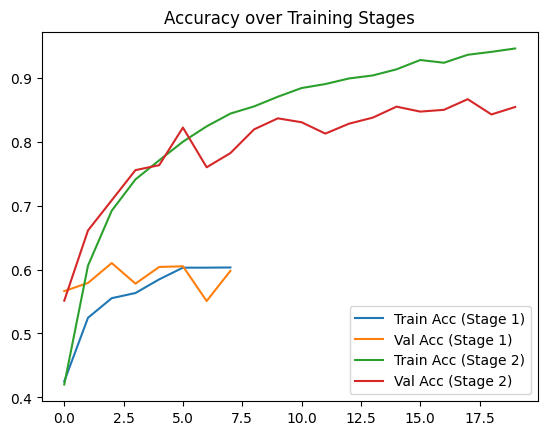

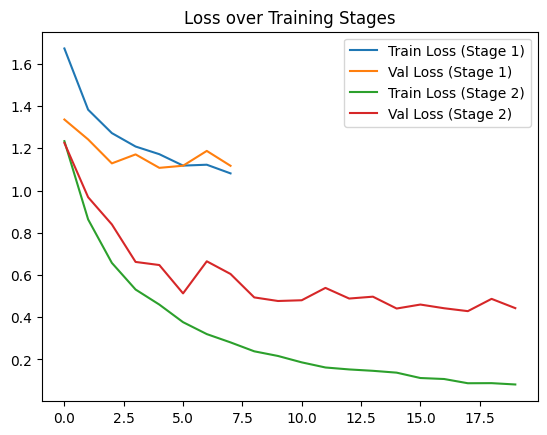

113/113 ━━━━━━━━━━━━━━━━━━━━ 82s 513ms/step

Validation Classification Report:

              precision    recall  f1-score   support

       akiec       0.62      0.75      0.68        59
         bcc       0.79      0.83      0.81        93
         bkl       0.82      0.80      0.81       198
          df       0.50      0.70      0.58        20
         mel       0.63      0.73      0.68       200
          nv       0.96      0.91      0.93      1207
        vasc       0.76      1.00      0.87        26

    accuracy                           0.87      1803
   macro avg       0.72      0.82      0.76      1803
weighted avg       0.88      0.87      0.87      1803



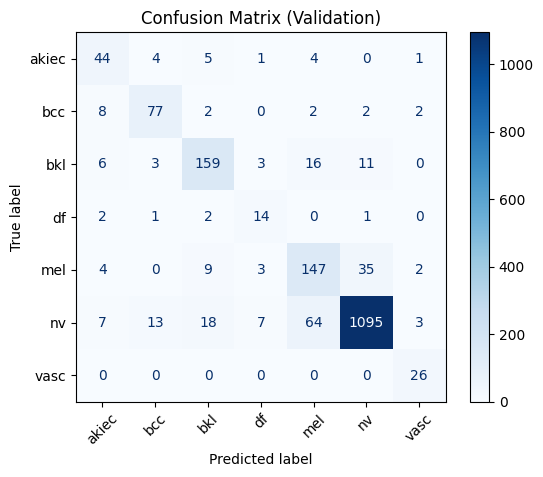

63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step

Test Classification Report:

              precision    recall  f1-score   support

       akiec       0.59      0.79      0.68        33
         bcc       0.82      0.90      0.86        51
         bkl       0.77      0.82      0.79       110
          df       0.50      0.67      0.57        12
         mel       0.67      0.72      0.70       111
          nv       0.96      0.90      0.93       671
        vasc       0.70      1.00      0.82        14

    accuracy                           0.87      1002
   macro avg       0.72      0.83      0.76      1002
weighted avg       0.88      0.87      0.87      1002



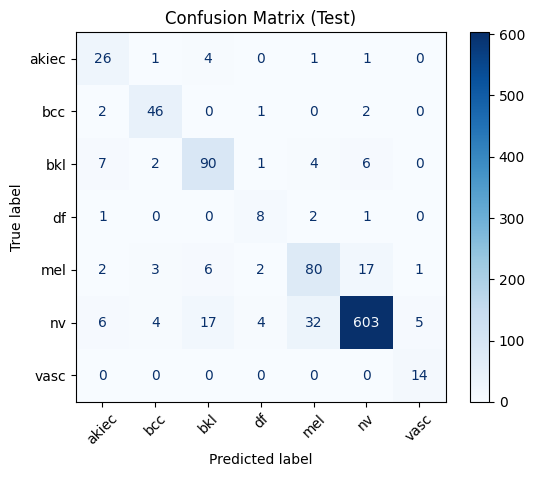

In [9]:

# Training curves
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc (Stage 1)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Stage 1)')
plt.plot(fine_tune_history.history['accuracy'], label='Train Acc (Stage 2)')
plt.plot(fine_tune_history.history['val_accuracy'], label='Val Acc (Stage 2)')
plt.legend(); plt.title("Accuracy over Training Stages")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss (Stage 1)')
plt.plot(history.history['val_loss'], label='Val Loss (Stage 1)')
plt.plot(fine_tune_history.history['loss'], label='Train Loss (Stage 2)')
plt.plot(fine_tune_history.history['val_loss'], label='Val Loss (Stage 2)')
plt.legend(); plt.title("Loss over Training Stages")
plt.show()

# Validation report
y_val_true = val_df['label'].values
y_val_pred = model.predict(val_ds).argmax(axis=1)

print("\nValidation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred, labels=range(num_classes))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.show()

# Test report
y_test_true = test_df['label'].values
y_test_pred = model.predict(test_ds).argmax(axis=1)

print("\nTest Classification Report:\n")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test_true, y_test_pred, labels=range(num_classes))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.show()




In [12]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effnet_preprocess

def predict_and_show_images(model, le, img_paths, target_size=(480, 480)):
    """
    Show predictions for given image paths with class and confidence only.
    Works with EfficientNetV2-L (expects 480x480 input).
    """
    idx_to_class = {i: label for i, label in enumerate(le.classes_)}
    
    plt.figure(figsize=(5*len(img_paths), 5))
    
    for i, img_path in enumerate(img_paths):
        # Load image at correct size
        img = image.load_img(img_path, target_size=target_size)
        img_array = np.expand_dims(image.img_to_array(img), axis=0)
        
        # Use EfficientNetV2 preprocessing
        img_array = effnet_preprocess(img_array)

        # Predict
        preds = model.predict(img_array, verbose=0)
        pred_idx = np.argmax(preds, axis=1)[0]
        pred_class = idx_to_class[pred_idx]
        confidence = np.max(preds)

        # Plot
        plt.subplot(1, len(img_paths), i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Pred: {pred_class}\nConf: {confidence:.2f}", fontsize=10)

    plt.tight_layout()
    plt.show()


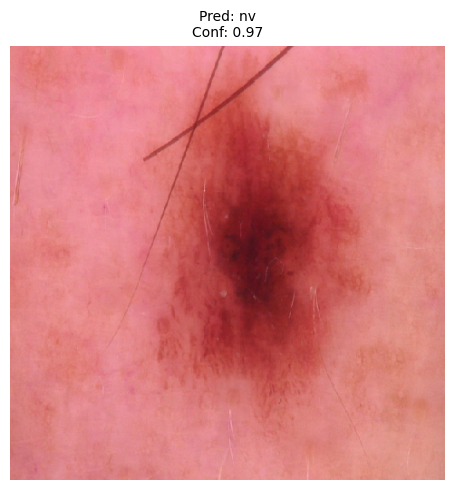

In [13]:

# List of your chosen image paths
sample_images = [
    "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024306.jpg" ]

predict_and_show_images(model, le, sample_images)
